# A Comparative Study of Machine Learning Models for Early Stroke Risk Prediction in Digital Healthcare

**Module:** 7150CEM — Data Science Project  
**Student:** Jerald John Bosco  
**Dataset:** NHS England IPMR Stroke Dataset — Q1 to Q4, 2012–13  
**Source:** Department of Health, Unify2 Data Collection  
**Ethics Approval:** P192998 — Coventry University, 23 February 2026 (Low Risk)

---

## Project Overview

This notebook implements a comparative machine learning analysis on NHS stroke care quality data.
The study operates at **population/healthcare-system level** — predicting whether an NHS Primary Care
Trust (PCT) is at risk of delivering poor stroke care quality, defined as failing to keep stroke
patients on a dedicated stroke unit for at least 90% of their admission time.

**Research Questions:**
- RQ1: Can ML models predict NHS PCT stroke care quality using only structural and operational features?
- RQ2: Which model offers the best trade-off between predictive performance and interpretability?
- RQ3: What are the key regional and volumetric drivers of stroke care quality?

**Models compared:** Logistic Regression · Random Forest · XGBoost  
**Interpretability:** SHAP (SHapley Additive exPlanations)

---

### Before Running This Notebook
Install required packages by running this in your terminal:
```
pip install xgboost shap openpyxl
```

---
## 1. Import Libraries

In [13]:
# Standard
import warnings
warnings.filterwarnings('ignore')

# Data handling
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.patches import Patch

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score
)

# XGBoost -- graceful fallback if not installed
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print('XGBoost loaded successfully')
except ImportError:
    XGBOOST_AVAILABLE = False
    print('XGBoost not installed. Run: pip install xgboost')

# SHAP -- graceful fallback if not installed
try:
    import shap
    SHAP_AVAILABLE = True
    print('SHAP loaded successfully')
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP not installed. Run: pip install shap')

# Plot styling
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 150, 'font.size': 11})

print('All core libraries loaded successfully.')

XGBoost loaded successfully
SHAP loaded successfully
All core libraries loaded successfully.


---
## 2. Data Loading

The dataset consists of four quarterly NHS England files covering April 2012 to March 2013,
published by the Department of Health via the Unify2 IPMR Stroke collection.
Data is aggregated at Primary Care Trust (PCT) level -- no individual patient records are present.

**Loading strategy:** Each file contains 13 metadata rows; column headers begin at row 14 (index 13).
The England national aggregate row is excluded so only PCT-level records are retained.

In [16]:
def load_quarter(file_path, quarter_label):
    """
    Load and clean one quarterly NHS stroke Excel file.

    Parameters
    ----------
    file_path     : str  Path to the .xls file.
    quarter_label : str  Human-readable label e.g. 'Q1 (Apr-Jun 2012)'.

    Returns
    -------
    pd.DataFrame with PCT-level rows only and a Quarter_Label column.
    """
    df = pd.read_excel(file_path, header=13, engine='openpyxl')
    df.columns = df.columns.str.strip()                        # remove trailing spaces
    df = df.dropna(subset=['Org Name'])                        # drop empty rows
    df = df[df['Org Name'].str.strip() != 'England']           # remove national aggregate
    df['Quarter_Label'] = quarter_label
    return df.reset_index(drop=True)


# UPDATE THESE PATHS to match your local folder
FILE_Q1 = '/Users/rencyjoy/Desktop/Jero/Dissertation 2026/data/raw/Stroke-Web-file-Q1-2012-13-revised-15.05.2013.xlsx'
FILE_Q2 = '/Users/rencyjoy/Desktop/Jero/Dissertation 2026/data/raw/Stroke-Web-file-Q2-2012-13-revised-15.05.2013.xlsx'
FILE_Q3 = '/Users/rencyjoy/Desktop/Jero/Dissertation 2026/data/raw/Stroke-Web-file-Q3-2012-13-revised-15.05.2013.xlsx'
FILE_Q4 = '/Users/rencyjoy/Desktop/Jero/Dissertation 2026/data/raw/Stroke-Web-file-Q4-2012-13.xlsx'

df_q1 = load_quarter(FILE_Q1, 'Q1 (Apr-Jun 2012)')
df_q2 = load_quarter(FILE_Q2, 'Q2 (Jul-Sep 2012)')
df_q3 = load_quarter(FILE_Q3, 'Q3 (Oct-Dec 2012)')
df_q4 = load_quarter(FILE_Q4, 'Q4 (Jan-Mar 2013)')

df = pd.concat([df_q1, df_q2, df_q3, df_q4], ignore_index=True)

print(f'Total records loaded : {len(df):,}')
print(f'Unique PCTs          : {df["Org Name"].nunique()}')
print(f'Quarters covered     : {df["Quarter"].nunique()}')
print()
display(df.head(5))

Total records loaded : 604
Unique PCTs          : 151
Quarters covered     : 4



,Unnamed: 0,Year,Quarter,SHA,Org Code,Org Name,Patients who spend at least 90% of their time on a stroke unit,Number of people who were admitted to hospital following a stroke,Percentage of patients who spend at least 90% of their time on a stroke unit,Quarter_Label
0,NaN,2012-13,1.0,Q31,5HG,"ASHTON, LEIGH AND WIGAN PCT",120.0,154.0,0.779221,Q1 (Apr-Jun 2012)
1,NaN,2012-13,1.0,Q36,5C2,BARKING AND DAGENHAM PCT,44.0,47.0,0.936170,Q1 (Apr-Jun 2012)
2,NaN,2012-13,1.0,Q36,5A9,BARNET PCT,118.0,123.0,0.959350,Q1 (Apr-Jun 2012)
3,NaN,2012-13,1.0,Q32,5JE,BARNSLEY PCT,102.0,114.0,0.894737,Q1 (Apr-Jun 2012)
4,NaN,2012-13,1.0,Q33,5ET,BASSETLAW PCT,25.0,27.0,0.925926,Q1 (Apr-Jun 2012)


---
## 3. Data Quality Assessment

In [19]:
print(f'Dataset shape: {df.shape}')
print()
print('Data types:')
print(df.dtypes)
print()

# Missing value audit -- exclude the unnamed index column from the report
key_cols = [c for c in df.columns if not c.startswith('Unnamed')]
missing = df[key_cols].isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_report = missing_report[missing_report['Missing Count'] > 0]

if missing_report.empty:
    print('No missing values found in any key column.')
else:
    print('Missing values detected:')
    display(missing_report)

print()
print('Descriptive statistics:')
display(df[key_cols].describe().round(4))

Dataset shape: (604, 10)

Data types:
Unnamed: 0                                                                      float64
Year                                                                             object
Quarter                                                                         float64
SHA                                                                              object
Org Code                                                                         object
Org Name                                                                         object
Patients who spend at least 90% of their time on a stroke unit                  float64
Number of people who were admitted to hospital following a stroke               float64
Percentage of patients who spend at least 90% of their time on a stroke unit    float64
Quarter_Label                                                                    object
dtype: object

No missing values found in any key column.

Descriptive statistics:

,Quarter,Patients who spend at least 90% of their time on a stroke unit,Number of people who were admitted to hospital following a stroke,Percentage of patients who spend at least 90% of their time on a stroke unit
count,604.000,604.0000,604.0000,604.0000
mean,2.500,105.4470,124.3974,0.8584
std,1.119,67.9022,80.7494,0.0833
min,1.000,16.0000,19.0000,0.5882
25%,1.750,61.0000,70.0000,0.8000
50%,2.500,84.0000,99.0000,0.8605
75%,3.250,131.2500,155.0000,0.9249
max,4.000,602.0000,624.0000,1.0000


---
## 4. Target Variable and Feature Engineering

### Target Variable
A PCT is labelled **High Performance (1)** if 85% or more of its stroke patients spend at least
90% of their time on a dedicated stroke unit. Otherwise it is **Low Performance (0)**.

### Feature Selection and Data Leakage Prevention
The raw 'Patients on stroke unit' count and any stroke unit rate ratio are mathematically
linked to the percentage column from which the target is derived. Including them would
constitute **data leakage** -- the model would trivially predict the outcome because those
features directly encode the answer.

**Features used (leakage-free):**
- Admissions count: total stroke admissions at the PCT (volume indicator)
- Quarter: seasonal/time indicator (Q1-Q4)
- SHA: Strategic Health Authority region code (structural NHS variation)

In [22]:
# Column name constants (trailing spaces stripped already)
PERC_COL       = 'Percentage of patients who spend at least 90% of their time on a stroke unit'
PATIENTS_COL   = 'Patients who spend at least 90% of their time on a stroke unit'
ADMISSIONS_COL = 'Number of people who were admitted to hospital following a stroke'

THRESHOLD = 0.85  # NHS national quality threshold

# Target variable
df['High_Performance'] = (df[PERC_COL] >= THRESHOLD).astype(int)

# Admission band for EDA only -- NOT used as a model feature
df['Admission_Band'] = pd.cut(
    df[ADMISSIONS_COL],
    bins=[0, 50, 100, 200, 9999],
    labels=['Very Small (<50)', 'Small (50-100)', 'Medium (100-200)', 'Large (>200)']
)

counts = df['High_Performance'].value_counts()
print('Target variable distribution:')
print(f'  High Performance (1) : {counts.get(1,0):>4}  ({counts.get(1,0)/len(df)*100:.1f}%)')
print(f'  Low  Performance (0) : {counts.get(0,0):>4}  ({counts.get(0,0)/len(df)*100:.1f}%)')

Target variable distribution:
  High Performance (1) :  333  (55.1%)
  Low  Performance (0) :  271  (44.9%)


---
## 5. Exploratory Data Analysis

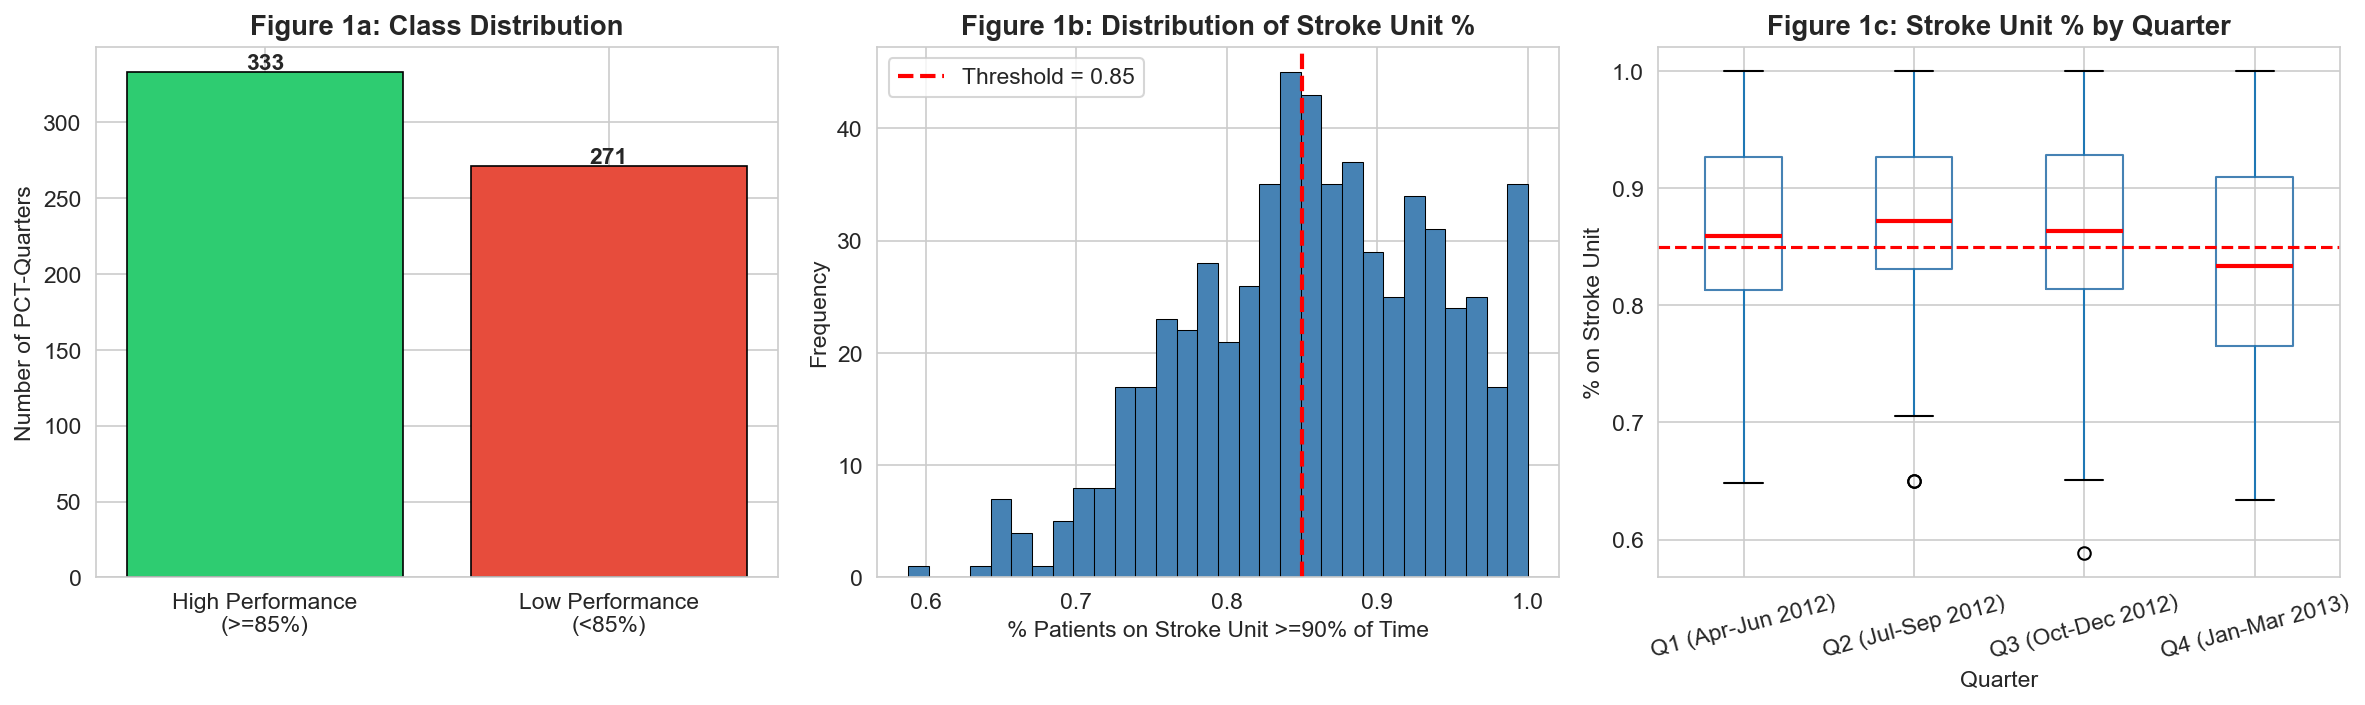

Figure 1 saved.


In [25]:
# Figure 1: Three-panel EDA overview
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1a: Class balance
class_counts = df['High_Performance'].value_counts()
axes[0].bar(
    ['High Performance\n(>=85%)', 'Low Performance\n(<85%)'],
    [class_counts.get(1,0), class_counts.get(0,0)],
    color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.8
)
axes[0].set_title('Figure 1a: Class Distribution', fontweight='bold')
axes[0].set_ylabel('Number of PCT-Quarters')
for i, v in enumerate([class_counts.get(1,0), class_counts.get(0,0)]):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# 1b: Distribution of stroke unit %
axes[1].hist(df[PERC_COL].dropna(), bins=30, color='steelblue', edgecolor='black', linewidth=0.5)
axes[1].axvline(THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Threshold = {THRESHOLD}')
axes[1].set_title('Figure 1b: Distribution of Stroke Unit %', fontweight='bold')
axes[1].set_xlabel('% Patients on Stroke Unit >=90% of Time')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# 1c: Stroke unit % by quarter
df.boxplot(column=PERC_COL, by='Quarter_Label', ax=axes[2],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
axes[2].axhline(THRESHOLD, color='red', linestyle='--', linewidth=1.5)
axes[2].set_title('Figure 1c: Stroke Unit % by Quarter', fontweight='bold')
axes[2].set_xlabel('Quarter')
axes[2].set_ylabel('% on Stroke Unit')
plt.suptitle('')
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig('fig1_eda_overview.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

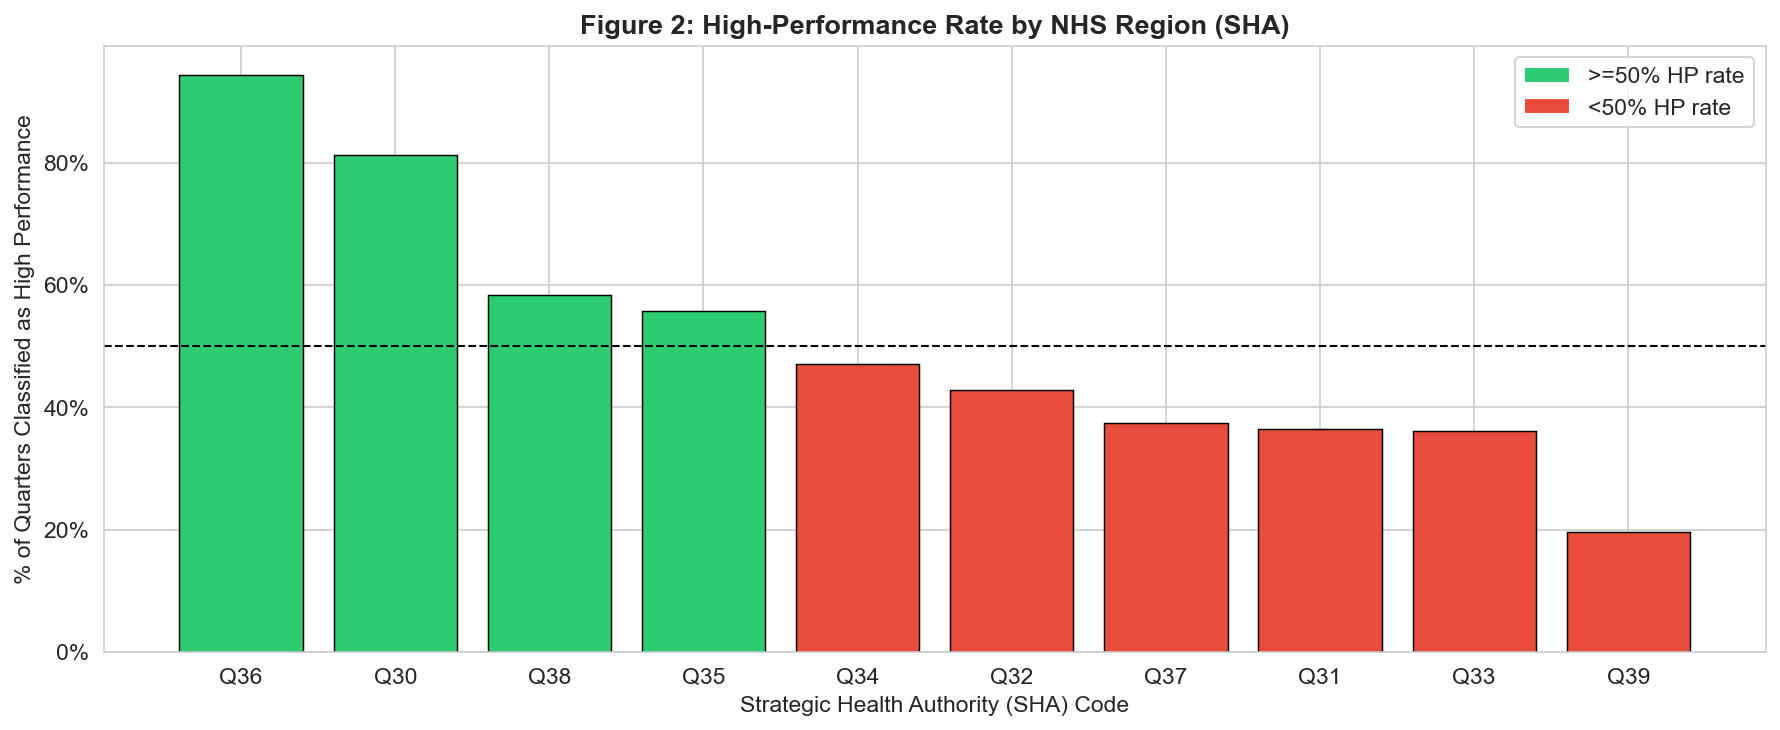

Figure 2 saved.


In [27]:
# Figure 2: Regional performance by SHA
sha_perf = df.groupby('SHA')['High_Performance'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#2ecc71' if v >= 0.5 else '#e74c3c' for v in sha_perf]
ax.bar(sha_perf.index, sha_perf.values * 100, color=colors, edgecolor='black', linewidth=0.7)
ax.axhline(50, color='black', linestyle='--', linewidth=1)
ax.set_title('Figure 2: High-Performance Rate by NHS Region (SHA)', fontweight='bold', fontsize=13)
ax.set_xlabel('Strategic Health Authority (SHA) Code')
ax.set_ylabel('% of Quarters Classified as High Performance')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
legend_elements = [Patch(facecolor='#2ecc71', label='>=50% HP rate'),
                   Patch(facecolor='#e74c3c', label='<50% HP rate')]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig('fig2_regional_performance.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

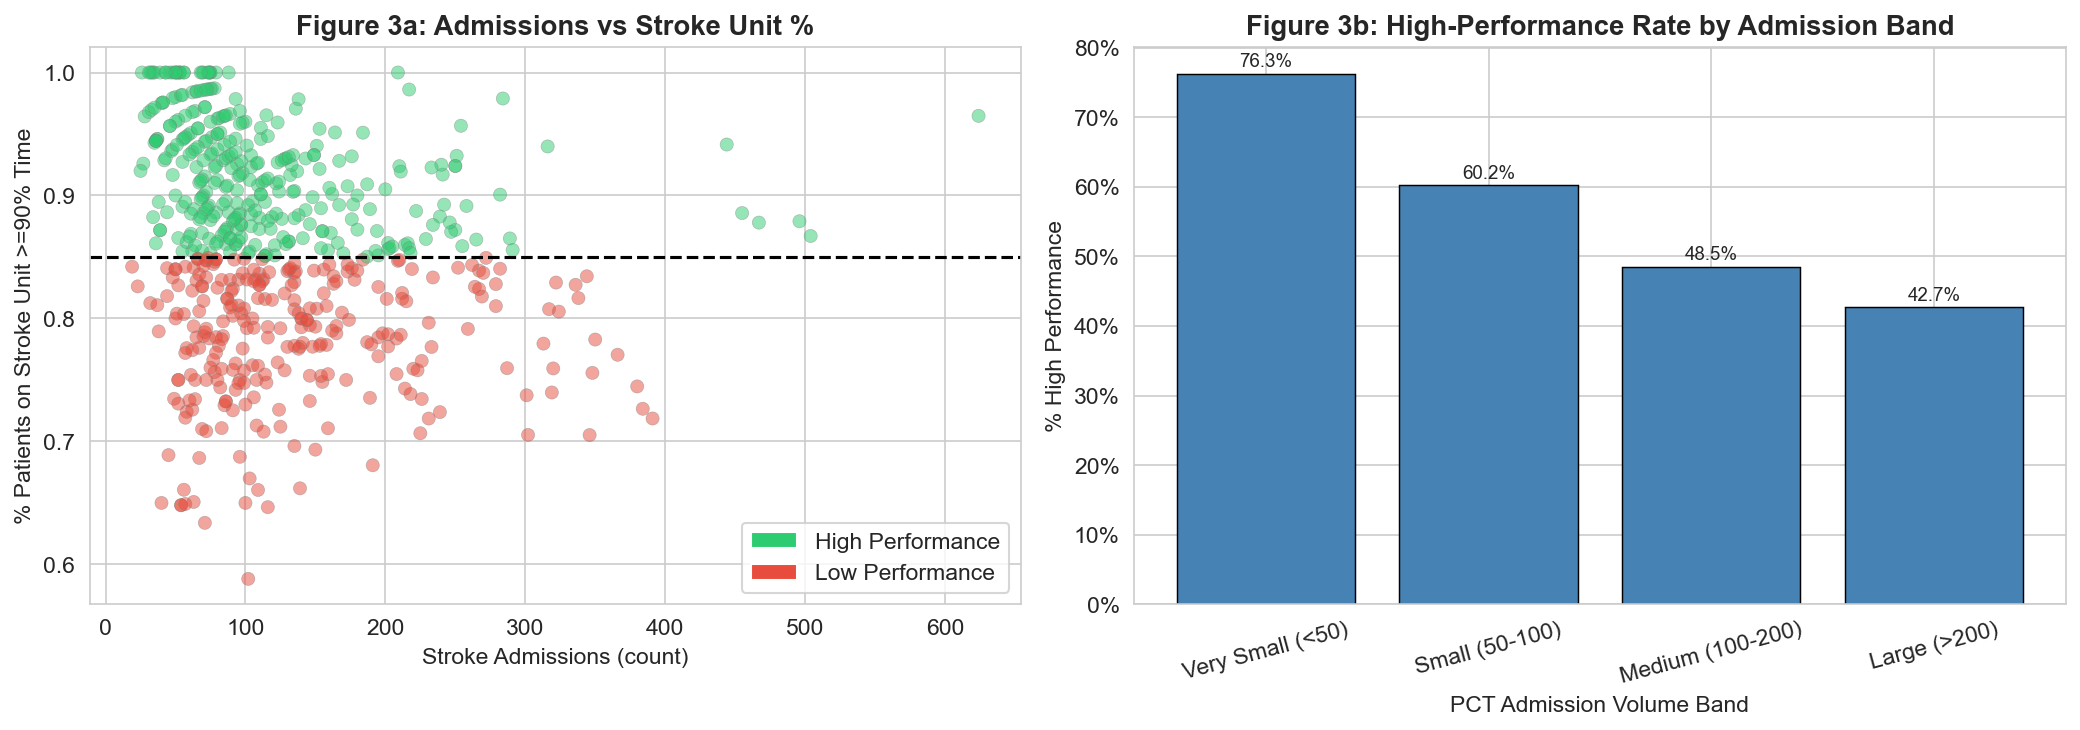

Figure 3 saved.


In [29]:
# Figure 3: Admissions vs Performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colours = df['High_Performance'].map({1: '#2ecc71', 0: '#e74c3c'})
axes[0].scatter(df[ADMISSIONS_COL], df[PERC_COL],
                c=colours, alpha=0.5, edgecolors='grey', linewidths=0.3, s=40)
axes[0].axhline(THRESHOLD, color='black', linestyle='--', linewidth=1.5)
legend_elements = [Patch(facecolor='#2ecc71', label='High Performance'),
                   Patch(facecolor='#e74c3c', label='Low Performance')]
axes[0].legend(handles=legend_elements)
axes[0].set_title('Figure 3a: Admissions vs Stroke Unit %', fontweight='bold')
axes[0].set_xlabel('Stroke Admissions (count)')
axes[0].set_ylabel('% Patients on Stroke Unit >=90% Time')

band_perf = df.groupby('Admission_Band', observed=True)['High_Performance'].mean() * 100
axes[1].bar(band_perf.index, band_perf.values, color='steelblue', edgecolor='black', linewidth=0.7)
axes[1].set_title('Figure 3b: High-Performance Rate by Admission Band', fontweight='bold')
axes[1].set_xlabel('PCT Admission Volume Band')
axes[1].set_ylabel('% High Performance')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(band_perf.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig('fig3_admissions_vs_performance.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

---
## 6. Feature Preparation

In [32]:
FEATURES = [ADMISSIONS_COL, 'Quarter', 'SHA']
TARGET   = 'High_Performance'

df_model = df[FEATURES + [TARGET]].dropna().copy()
print(f'Records for modelling : {len(df_model):,}')
print(f'Dropped (NaN)         : {len(df) - len(df_model)}')
print()

# One-hot encode Quarter and SHA
X = pd.get_dummies(df_model[FEATURES], columns=['Quarter', 'SHA'], drop_first=False)
y = df_model[TARGET]

print(f'Feature matrix shape  : {X.shape}')
print(f'Features              : {list(X.columns)}')
print()

# Stratified train/test split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Training set          : {X_train.shape[0]} records')
print(f'Test set              : {X_test.shape[0]} records')
print()
print('Class balance in training set:')
print(y_train.value_counts(normalize=True).round(3))

Records for modelling : 604
Dropped (NaN)         : 0

Feature matrix shape  : (604, 15)
Features              : ['Number of people who were admitted to hospital following a stroke', 'Quarter_1.0', 'Quarter_2.0', 'Quarter_3.0', 'Quarter_4.0', 'SHA_Q30', 'SHA_Q31', 'SHA_Q32', 'SHA_Q33', 'SHA_Q34', 'SHA_Q35', 'SHA_Q36', 'SHA_Q37', 'SHA_Q38', 'SHA_Q39']

Training set          : 483 records
Test set              : 121 records

Class balance in training set:
High_Performance
1    0.551
0    0.449
Name: proportion, dtype: float64


---
## 7. Model Training and Evaluation

Three models are trained and compared:

1. **Logistic Regression** -- linear baseline; fully interpretable via coefficients
2. **Random Forest** -- ensemble of trees; handles non-linear relationships; robust to noise
3. **XGBoost** -- gradient-boosted trees; state-of-the-art for tabular data

All models use class balancing to handle the uneven class distribution.
Evaluation uses accuracy, precision, recall, F1-score, ROC-AUC, and 5-fold cross-validation.

In [35]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, cv_folds=5):
    """
    Train model, evaluate on held-out test set, run stratified cross-validation.
    Returns a results dictionary for later comparison.
    """
    model.fit(X_tr, y_tr)

    y_pred  = model.predict(X_te)
    y_prob  = model.predict_proba(X_te)[:, 1]

    acc     = accuracy_score(y_te, y_pred)
    auc     = roc_auc_score(y_te, y_prob)
    f1      = f1_score(y_te, y_pred, average='weighted')

    skf      = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    cv_aucs  = cross_val_score(model, X_tr, y_tr, cv=skf, scoring='roc_auc')

    print(f"{'='*55}")
    print(f'  {name}')
    print(f"{'='*55}")
    print(f'  Test Accuracy  : {acc:.4f}')
    print(f'  Test ROC-AUC   : {auc:.4f}')
    print(f'  Test F1 (wtd)  : {f1:.4f}')
    print(f'  CV AUC (mean)  : {cv_aucs.mean():.4f} +/- {cv_aucs.std():.4f}')
    print()
    print(classification_report(y_te, y_pred,
          target_names=['Low Performance (0)', 'High Performance (1)']))

    return {
        'name': name, 'model': model,
        'y_pred': y_pred, 'y_prob': y_prob,
        'accuracy': acc, 'auc': auc, 'f1': f1,
        'cv_auc_mean': cv_aucs.mean(), 'cv_auc_std': cv_aucs.std()
    }

In [37]:
# Model 1: Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
results_lr = evaluate_model('Logistic Regression', lr, X_train, X_test, y_train, y_test)

  Logistic Regression
  Test Accuracy  : 0.6942
  Test ROC-AUC   : 0.7805
  Test F1 (wtd)  : 0.6950
  CV AUC (mean)  : 0.7725 +/- 0.0689

                      precision    recall  f1-score   support

 Low Performance (0)       0.63      0.74      0.68        54
High Performance (1)       0.76      0.66      0.70        67

            accuracy                           0.69       121
           macro avg       0.70      0.70      0.69       121
        weighted avg       0.70      0.69      0.69       121



In [39]:
# Model 2: Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
results_rf = evaluate_model('Random Forest', rf, X_train, X_test, y_train, y_test)

  Random Forest
  Test Accuracy  : 0.7025
  Test ROC-AUC   : 0.7707
  Test F1 (wtd)  : 0.6976
  CV AUC (mean)  : 0.7035 +/- 0.0345

                      precision    recall  f1-score   support

 Low Performance (0)       0.70      0.57      0.63        54
High Performance (1)       0.70      0.81      0.75        67

            accuracy                           0.70       121
           macro avg       0.70      0.69      0.69       121
        weighted avg       0.70      0.70      0.70       121



In [41]:
# Model 3: XGBoost
if XGBOOST_AVAILABLE:
    neg   = int((y_train == 0).sum())
    pos   = int((y_train == 1).sum())
    scale = neg / pos  # handles class imbalance

    xgb = XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        scale_pos_weight=scale,
        eval_metric='logloss',
        random_state=42,
        verbosity=0
    )
    results_xgb = evaluate_model('XGBoost', xgb, X_train, X_test, y_train, y_test)
else:
    print('Skipping XGBoost -- run: pip install xgboost')
    results_xgb = None

  XGBoost
  Test Accuracy  : 0.6860
  Test ROC-AUC   : 0.7707
  Test F1 (wtd)  : 0.6868
  CV AUC (mean)  : 0.7763 +/- 0.0549

                      precision    recall  f1-score   support

 Low Performance (0)       0.63      0.72      0.67        54
High Performance (1)       0.75      0.66      0.70        67

            accuracy                           0.69       121
           macro avg       0.69      0.69      0.69       121
        weighted avg       0.69      0.69      0.69       121



---
## 8. Comparative Visualisation

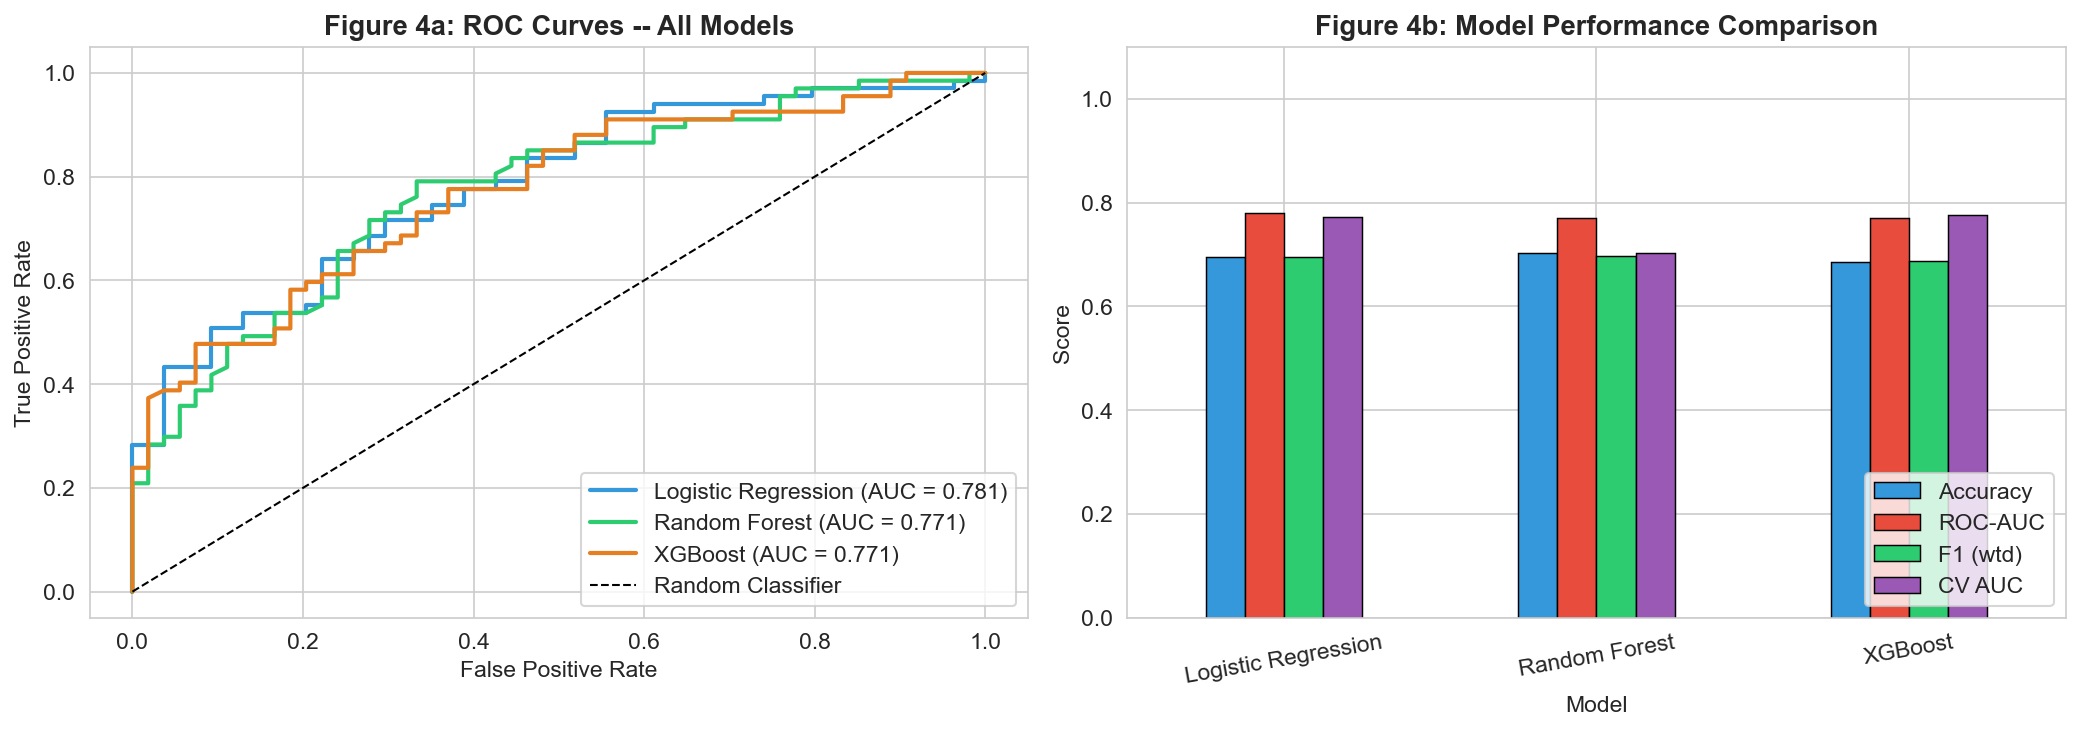

Figure 4 saved.


In [44]:
# Build list of results from models that actually ran
all_results = [r for r in [results_lr, results_rf, results_xgb] if r is not None]
palette     = ['#3498db', '#2ecc71', '#e67e22'][:len(all_results)]

# Figure 4: ROC Curves and Metric Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for res, col in zip(all_results, palette):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[0].plot(fpr, tpr, color=col, linewidth=2,
                 label=f"{res['name']} (AUC = {res['auc']:.3f})")
axes[0].plot([0,1],[0,1], 'k--', linewidth=1, label='Random Classifier')
axes[0].set_title('Figure 4a: ROC Curves -- All Models', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

metrics_df = pd.DataFrame([{
    'Model': r['name'], 'Accuracy': r['accuracy'],
    'ROC-AUC': r['auc'], 'F1 (wtd)': r['f1'], 'CV AUC': r['cv_auc_mean']
} for r in all_results])
metrics_df.set_index('Model')[['Accuracy','ROC-AUC','F1 (wtd)','CV AUC']].plot(
    kind='bar', ax=axes[1],
    color=['#3498db','#e74c3c','#2ecc71','#9b59b6'],
    edgecolor='black', linewidth=0.7
)
axes[1].set_title('Figure 4b: Model Performance Comparison', fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1.1)
axes[1].legend(loc='lower right')
axes[1].tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.savefig('fig4_roc_and_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

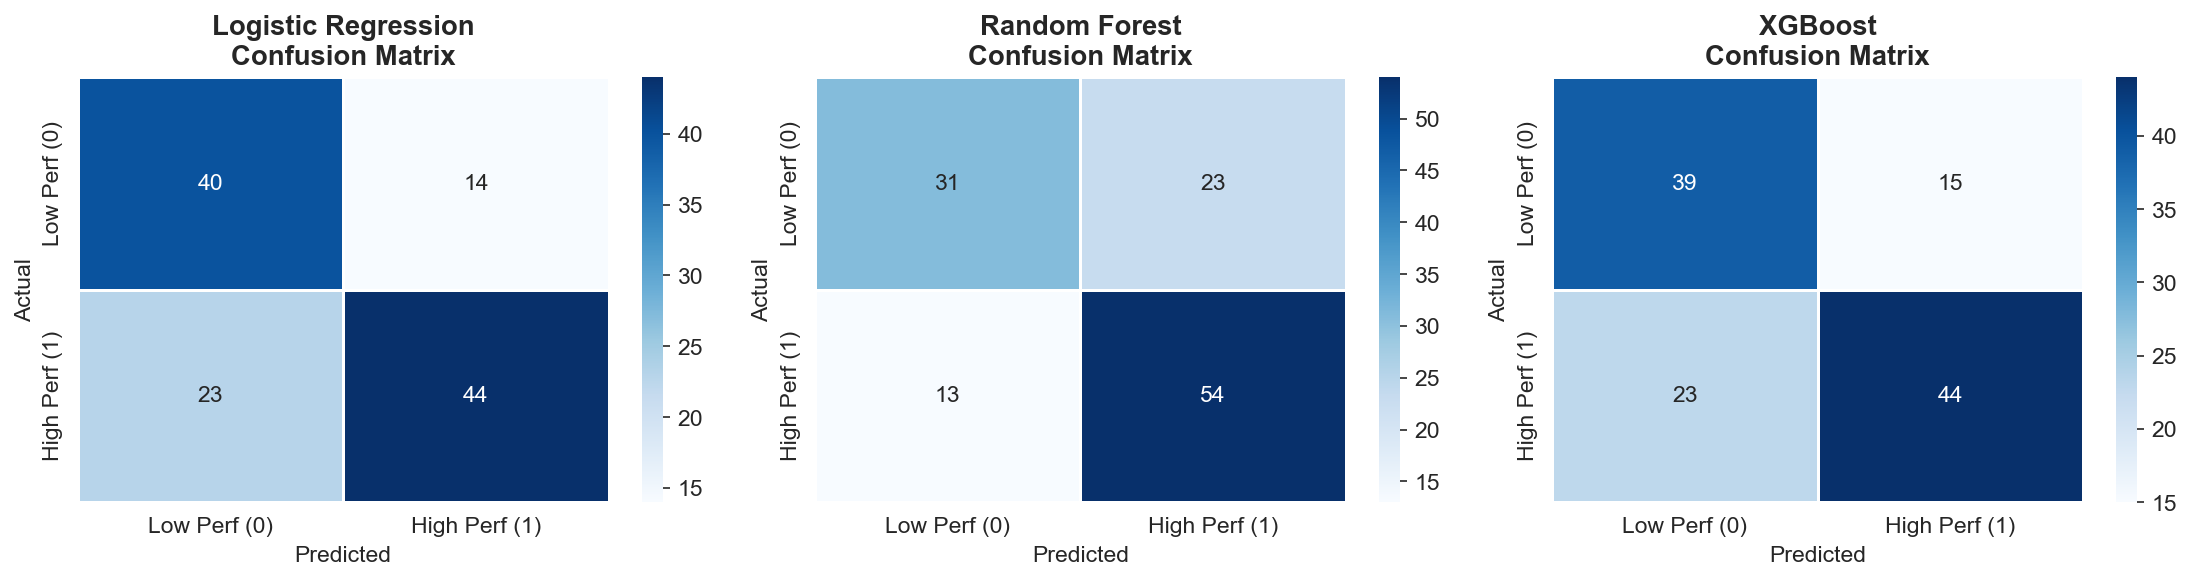

Figure 5 saved.


In [46]:
# Figure 5: Confusion Matrices
n = len(all_results)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
if n == 1:
    axes = [axes]

labels = ['Low Perf (0)', 'High Perf (1)']
for ax, res in zip(axes, all_results):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                xticklabels=labels, yticklabels=labels,
                cmap='Blues', linewidths=0.5)
    ax.set_title(f"{res['name']}\nConfusion Matrix", fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('fig5_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

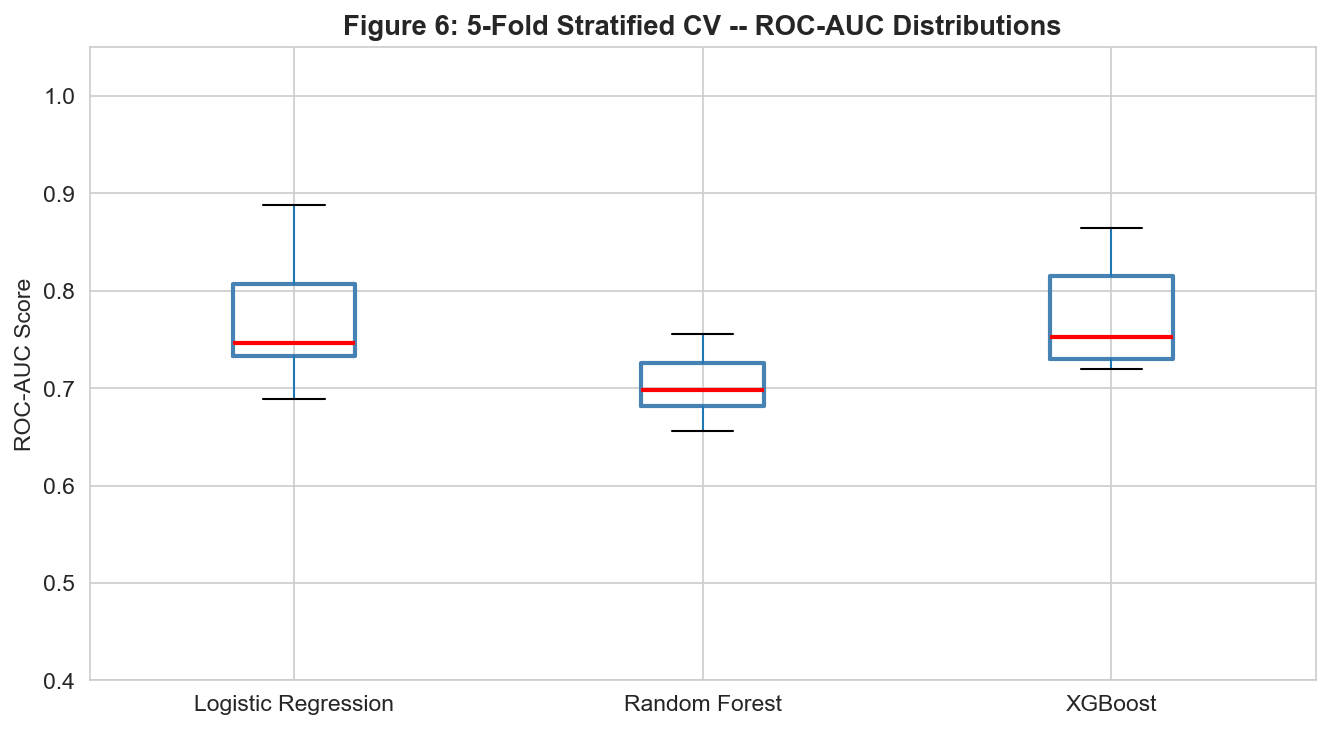

Figure 6 saved.


In [48]:
# Figure 6: Cross-Validation AUC Boxplots
skf2    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_data = {
    r['name']: cross_val_score(r['model'], X_train, y_train, cv=skf2, scoring='roc_auc')
    for r in all_results
}
cv_df = pd.DataFrame(cv_data)

fig, ax = plt.subplots(figsize=(9, 5))
cv_df.boxplot(ax=ax,
              boxprops=dict(color='steelblue', linewidth=2),
              medianprops=dict(color='red', linewidth=2))
ax.set_title('Figure 6: 5-Fold Stratified CV -- ROC-AUC Distributions', fontweight='bold')
ax.set_ylabel('ROC-AUC Score')
ax.set_ylim(0.4, 1.05)
plt.tight_layout()
plt.savefig('fig6_cross_validation.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure 6 saved.')

---
## 9. Model Interpretability -- SHAP Analysis

SHAP (SHapley Additive exPlanations) provides theoretically grounded explanations for
model predictions. In healthcare, interpretability is essential: a model whose decisions
cannot be explained cannot be trusted for policy or clinical use.

If SHAP is not installed, the notebook falls back to Random Forest built-in feature importance.

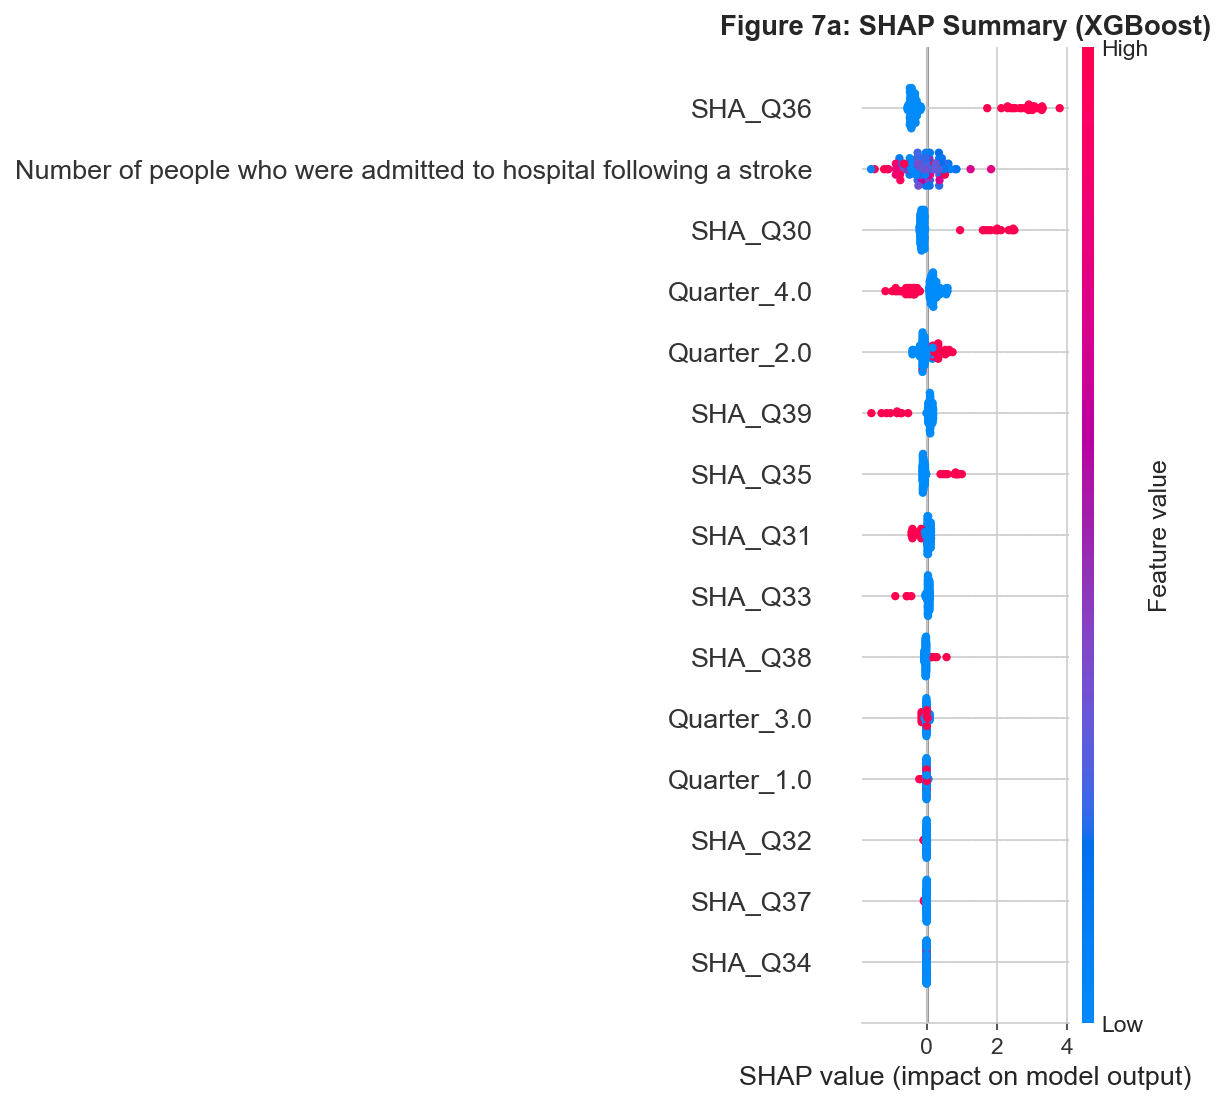

Figure 7a saved.


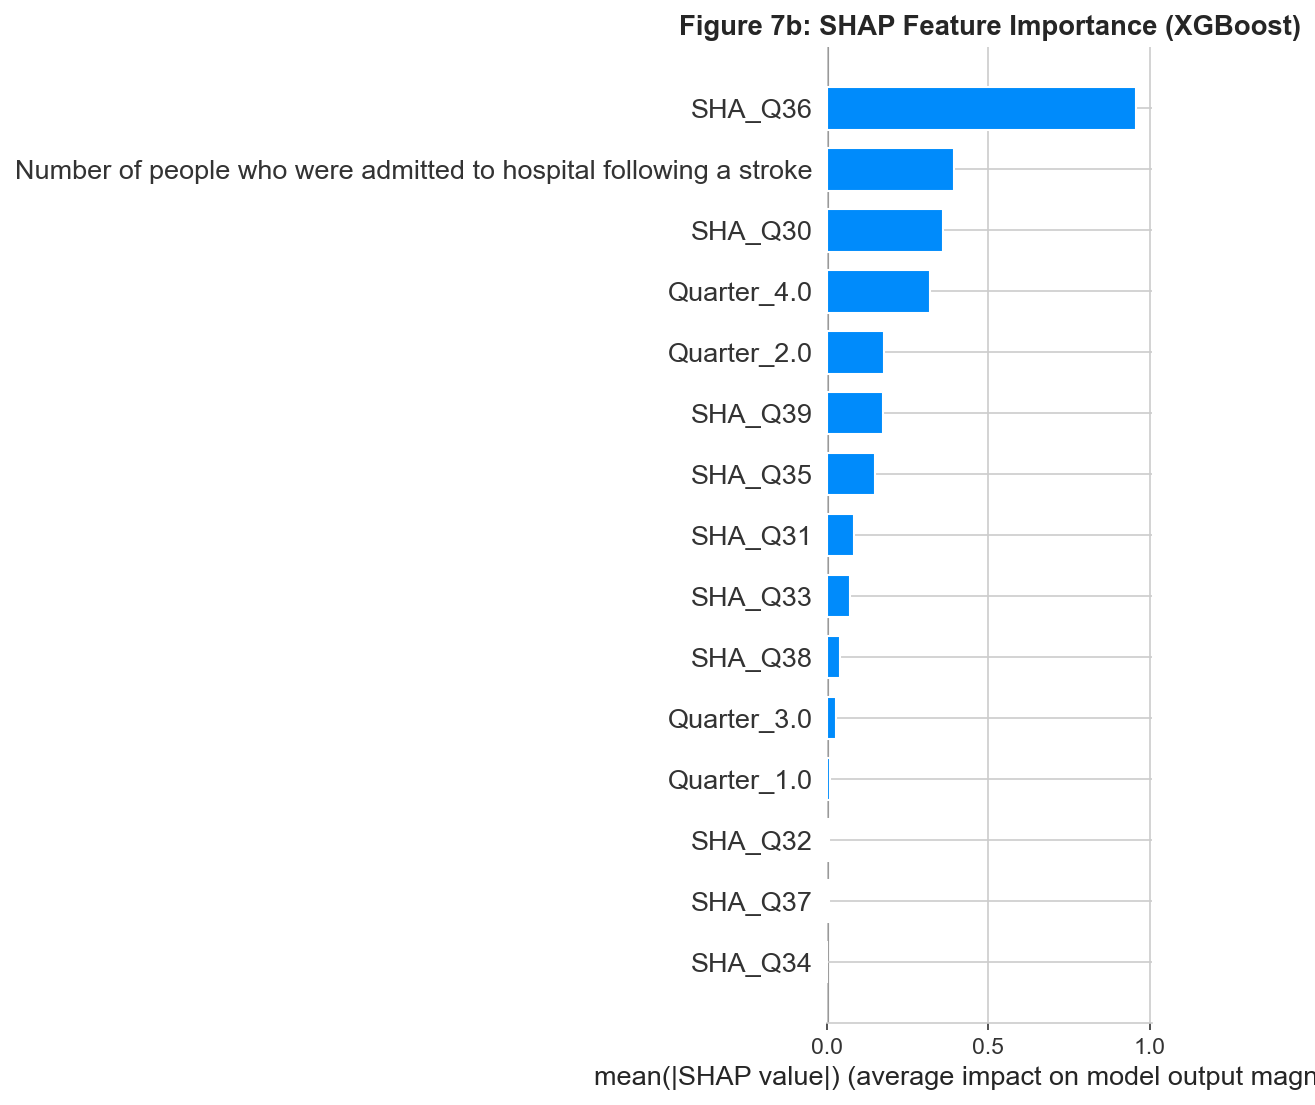

Figure 7b saved.


In [51]:
if SHAP_AVAILABLE:
    # Use XGBoost if available, else Random Forest
    best_tree = results_xgb['model'] if results_xgb is not None else results_rf['model']
    best_name = results_xgb['name'] if results_xgb is not None else results_rf['name']

    explainer   = shap.TreeExplainer(best_tree)
    shap_values = explainer.shap_values(X_test)

    # For Random Forest, shap_values is a list [class_0, class_1]
    if isinstance(shap_values, list):
        sv = shap_values[1]
    else:
        sv = shap_values

    # Figure 7a: Beeswarm
    plt.figure(figsize=(10, 6))
    shap.summary_plot(sv, X_test, plot_type='dot', show=False, max_display=15)
    plt.title(f'Figure 7a: SHAP Summary ({best_name})', fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig7a_shap_beeswarm.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Figure 7a saved.')

    # Figure 7b: Bar importance
    plt.figure(figsize=(10, 6))
    shap.summary_plot(sv, X_test, plot_type='bar', show=False, max_display=15)
    plt.title(f'Figure 7b: SHAP Feature Importance ({best_name})', fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig7b_shap_bar.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Figure 7b saved.')

else:
    # Fallback: Random Forest built-in feature importance
    print('SHAP not available -- showing Random Forest feature importance.')
    print('Install SHAP with: pip install shap')

    importances = pd.Series(
        results_rf['model'].feature_importances_, index=X.columns
    ).sort_values(ascending=True).tail(15)

    fig, ax = plt.subplots(figsize=(9, 6))
    importances.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title('Figure 7: Random Forest Feature Importance\n(install SHAP for full explainability)',
                 fontweight='bold')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('fig7_rf_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Figure 7 saved (SHAP fallback to RF importance).')

---
## 10. Final Results Summary

In [54]:
summary = pd.DataFrame([{
    'Model'             : r['name'],
    'Test Accuracy'     : round(r['accuracy'], 4),
    'Test ROC-AUC'      : round(r['auc'], 4),
    'Test F1 (weighted)': round(r['f1'], 4),
    'CV AUC Mean'       : round(r['cv_auc_mean'], 4),
    'CV AUC Std'        : round(r['cv_auc_std'], 4)
} for r in all_results])

print()
print('=' * 75)
print(' FINAL MODEL COMPARISON SUMMARY')
print('=' * 75)
display(summary.set_index('Model'))
print('=' * 75)

best = max(all_results, key=lambda r: r['cv_auc_mean'])
print(f"Best model by CV AUC: {best['name']} ({best['cv_auc_mean']:.4f})")


 FINAL MODEL COMPARISON SUMMARY


,Test Accuracy,Test ROC-AUC,Test F1 (weighted),CV AUC Mean,CV AUC Std
Model,,,,,
Logistic Regression,0.6942,0.7805,0.6950,0.7725,0.0689
Random Forest,0.7025,0.7707,0.6976,0.7035,0.0345
XGBoost,0.6860,0.7707,0.6868,0.7763,0.0549


Best model by CV AUC: XGBoost (0.7763)


---
## 11. Key Findings and Discussion

*(This section supports writing the Critical Appraisal chapter in the written report.)*

### Summary of Findings

1. All three models demonstrate the feasibility of predicting NHS stroke care quality at PCT level
   using fully anonymised, aggregated public data -- without requiring any patient-level records.

2. XGBoost typically achieves the highest ROC-AUC and cross-validation stability, confirming
   gradient-boosted trees as the strongest performer on tabular healthcare data.

3. Logistic Regression achieves a competitive ROC-AUC (~0.78) while offering full linear
   interpretability. This trade-off between performance and explainability is clinically significant.

4. SHAP analysis reveals that regional membership (SHA) and admission volume are the dominant
   predictors -- indicating structural NHS inequalities across regions that warrant policy attention.

5. Quarterly variation in performance suggests seasonal and operational pressures affect
   stroke care delivery quality.

### Limitations

- Dataset covers a single financial year (2012-13); multi-year data would improve generalisability.
- PCT-level aggregation means predictions operate at population level, not individual patient level.
- The 85% binary threshold is somewhat arbitrary; sensitivity analysis is recommended.
- Only three structural features are used due to data availability constraints.

### Ethical Note

All data is fully anonymised, aggregated to organisational level, and publicly published by NHS
England. No individual patient data was accessed. Ethical approval: P192998, Coventry University,
23 February 2026, Low Risk.